# CS106 - Sesión 8 | Notebook 37: Comparando Promedios (t-Student) 🌡️

La **Prueba t de Student** es el método estándar para determinar si la diferencia entre las medias de dos grupos independientes es estadísticamente significativa.

### Concepto Visual: Solapamiento de Poblaciones
Imagina las distribuciones (campanas de Gauss) de dos grupos. La prueba t mide qué tanto se enciman estas curvas:
* **Bajo solapamiento:** Las medias están distantes; la diferencia es probablemente real (**p < 0.05**).
* **Alto solapamiento:** Las curvas están casi una sobre otra; la diferencia se debe probablemente al azar (**p > 0.05**).

## 1. Inspección Visual de Densidad
Antes de calcular el valor *p*, observamos las curvas. Analizaremos la variable `edad` según el estado de `hospitalizado`. Si las "cimas" de las curvas están alejadas, es probable que exista significancia.

Rows: 200 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): nombre, sexo, diagnostico
dbl (5): id_paciente, edad, glucosa_mgdl, peso_kg, estatura_m
lgl (1): hospitalizado

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


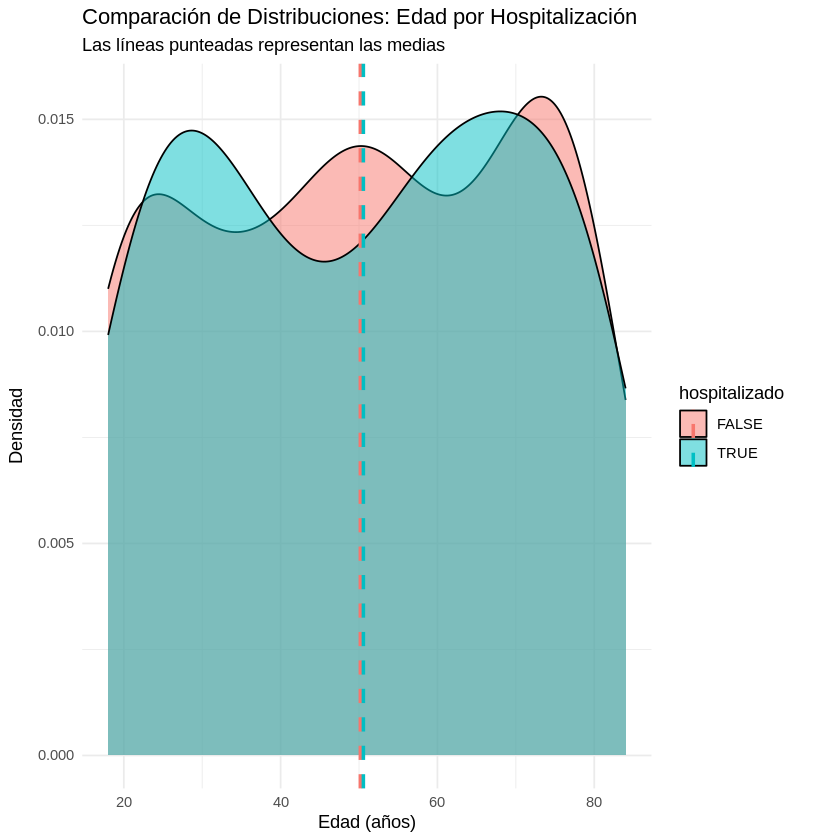

In [ ]:
library(tidyverse)
datos <- read_csv("cohorte_analisis.csv")

# Visualización de curvas de densidad comparativas
ggplot(datos, aes(x = edad, fill = hospitalizado)) +
  geom_density(alpha = 0.5) +
  geom_vline(data = datos |> group_by(hospitalizado) |> summarize(m = mean(edad)),
             aes(xintercept = m, color = hospitalizado),
             linetype = "dashed", linewidth = 1) +
  labs(title = "Comparación de Distribuciones: Edad por Hospitalización",
       subtitle = "Las líneas punteadas representan las medias",
       x = "Edad (años)", y = "Densidad") +
  theme_minimal()

## 2. El Veredicto Estadístico
Tras la observación, procedemos al cálculo. El **valor p** dará la evidencia para el reporte científico. Usaremos un Boxplot con puntos (*jitter*) para ver la dispersión real de los pacientes.


	Welch Two Sample t-test

data:  edad by hospitalizado
t = -0.12211, df = 126.1, p-value = 0.903
alternative hypothesis: true difference in means between group FALSE and group TRUE is not equal to 0
95 percent confidence interval:
 -6.597969  5.831017
sample estimates:
mean in group FALSE  mean in group TRUE 
           50.17037            50.55385 



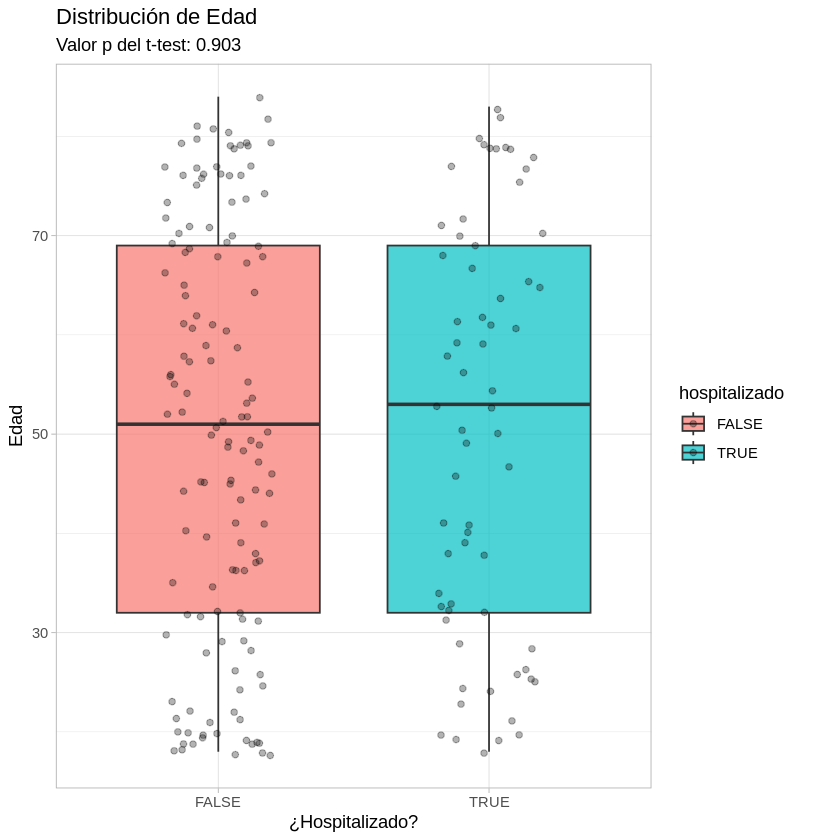

In [ ]:
# Ejecución de la prueba t (Edad vs Hospitalización)
resultado_t <- t.test(edad ~ hospitalizado, data = datos)
print(resultado_t)

# Boxplot con puntos reales
ggplot(datos, aes(x = hospitalizado, y = edad, fill = hospitalizado)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.2, alpha = 0.3) +
  labs(title = "Distribución de Edad",
       subtitle = paste("Valor p del t-test:", round(resultado_t$p.value, 4)),
       x = "¿Hospitalizado?", y = "Edad") +
  theme_light()

## 3. Reporte Masivo y .data[[var]]
Para analizar múltiples variables usamos ciclos (*loops*). Como el nombre de la variable cambia en cada vuelta, usamos la sintaxis **`.data[[var]]`** para que R encuentre la columna correcta en la tabla.

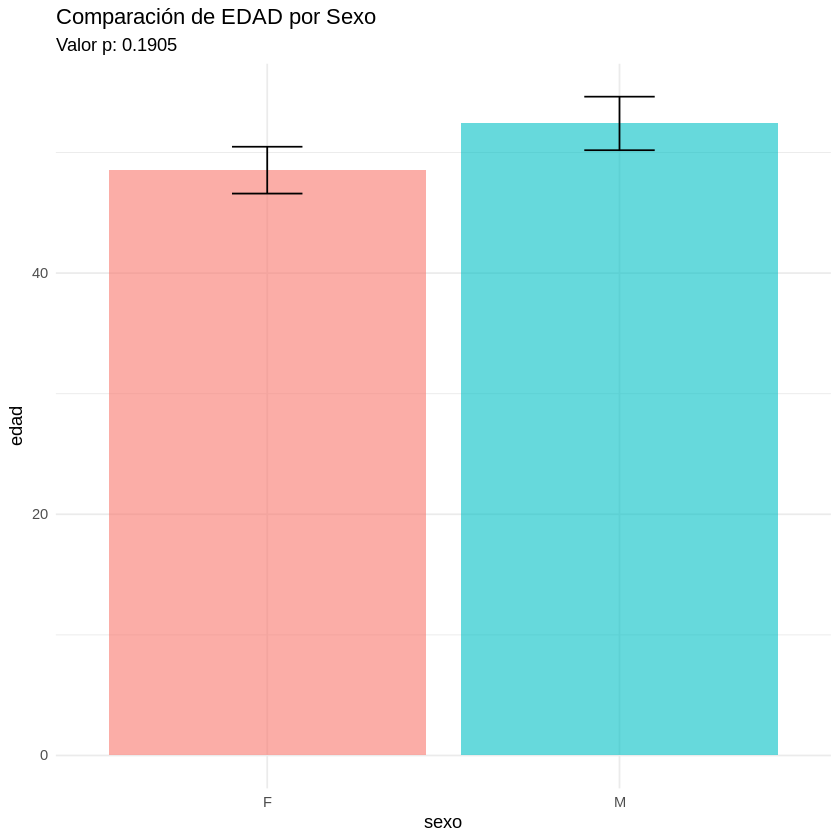

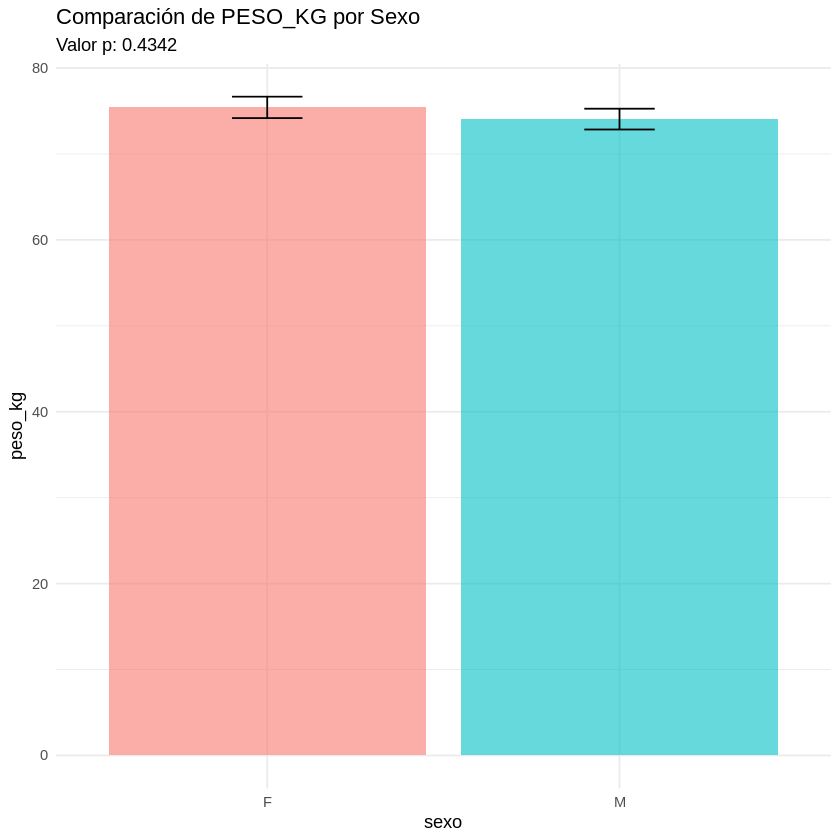

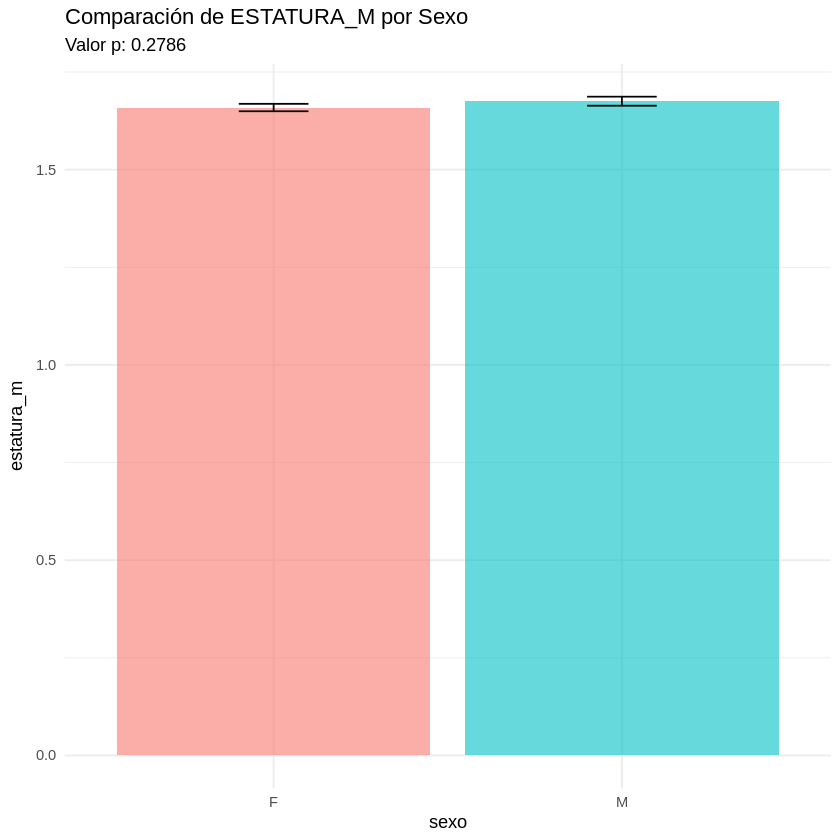

In [ ]:
variables_normales <- c("edad", "peso_kg", "estatura_m")

for (var in variables_normales) {
  test <- t.test(datos[[var]] ~ datos$sexo)

  p <- ggplot(datos, aes(x = sexo, y = .data[[var]], fill = sexo)) +
      stat_summary(fun = mean, geom = "bar", alpha = 0.6) +
      stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.2) +
      labs(title = paste("Comparación de", toupper(var), "por Sexo"),
           subtitle = paste("Valor p:", round(test$p.value, 4))) +
      theme_minimal() + theme(legend.position = "none")

  print(p)
}

## 4. Análisis Integral e Interpretación Clínica
Se realiza el análisis comparativo del **`peso_kg`** según el estado de **`hospitalizado`**.

**Tu misión:**
1. Analiza el reporte del t-test (valor p e intervalo de confianza).
2. Completa las variables de respuesta basándote en la evidencia del código ejecutado.

In [ ]:
# --- 1. CÓDIGO INTEGRAL DE ANÁLISIS ---
# No modificar: Ejecuta t-test y muestra resultados
resultado_final <- t.test(peso_kg ~ hospitalizado, data = datos)
print(resultado_final)

# --- 2. SECCIÓN DE RESPUESTAS (RELLENA LOS VALORES) ---

# r1: Valor p exacto observado (con 4 decimales)
r1_p_valor <- 0.0000

# r2: ¿Es la diferencia estadísticamente significativa? (TRUE o FALSE)
r2_significativo <- NULL

# r3: ¿El intervalo de confianza incluye el valor cero? (TRUE o FALSE)
r3_incluye_cero <- NULL

# --- 3. CONSTRUCCIÓN DEL DATA FRAME ---
df_respuesta <- data.frame(
  pregunta = c("p_valor", "significancia", "ic_cero"),
  respuesta = c(as.character(r1_p_valor), as.character(r2_significativo), as.character(r3_incluye_cero))
)
print(df_respuesta)


	Welch Two Sample t-test

data:  peso_kg by hospitalizado
t = -0.77663, df = 148.45, p-value = 0.4386
alternative hypothesis: true difference in means between group FALSE and group TRUE is not equal to 0
95 percent confidence interval:
 -4.836388  2.107385
sample estimates:
mean in group FALSE  mean in group TRUE 
           74.35704            75.72154 

       pregunta respuesta
1       p_valor         0
2 significancia         0
3       ic_cero         0


In [ ]:
# Ejecuta para guardar tu avance
source("utilidades.r")
guardar_37(df_respuesta)